# **Classification on Spam Email**

# 1. Load Necessary Libraries

In [1]:
# for data
import pandas as pd
import numpy as np

# for visualization
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.graph_objs as go
from wordcloud import WordCloud


# nltk used for NLP
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Preprocessing (sklearn)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Modeling
from sklearn.ensemble import RandomForestClassifier
from lightgbm.sklearn import LGBMClassifier
import xgboost as xgb
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, GlobalMaxPooling1D, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import regularizers
import tensorflow as tf

# scoring
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, RocCurveDisplay
nltk.download('punkt')     # Tokenizer
nltk.download('wordnet')   # Lemmatization Dictionary 
nltk.download('stopwords') # Stopword List

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/qiufanchen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/qiufanchen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/qiufanchen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Exploratory Data Analysis (EDA)

In [2]:
# Note: This light preprocessing (lowercasing, removing punctuation, etc.) is only for EDA. 
# The actual model training will use a separate, standardized preprocessing pipeline in '3. Text Preprocessing'.

In [63]:
# Load the CSV file
# df = pd.read_csv("spam.csv", encoding='latin-1')
df = pd.read_csv("/Users/qiufanchen/Downloads/spam.csv", encoding='latin-1')

In [65]:
# Display the first few rows of the dataset
print("First 5 records of the dataset:")
df.head(5)

First 5 records of the dataset:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Count how many messages are ham vs spam
class_counts = df['Category'].value_counts()
print("\nMessage count by category:")
print(class_counts)


Message count by category:
Category
ham     4825
spam     747
Name: count, dtype: int64


## 2.1 Class Distribution

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/3868394788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='pastel')


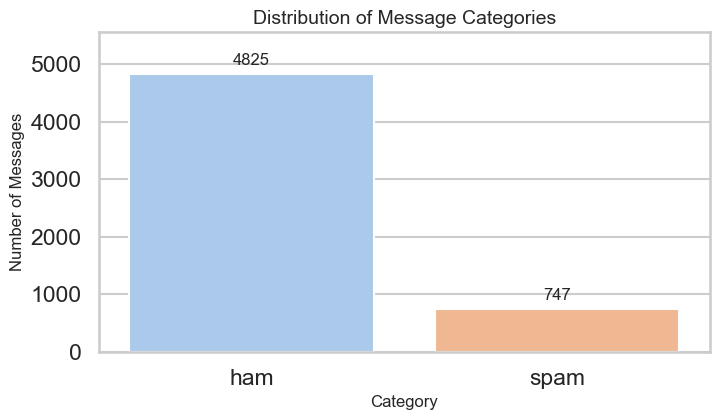

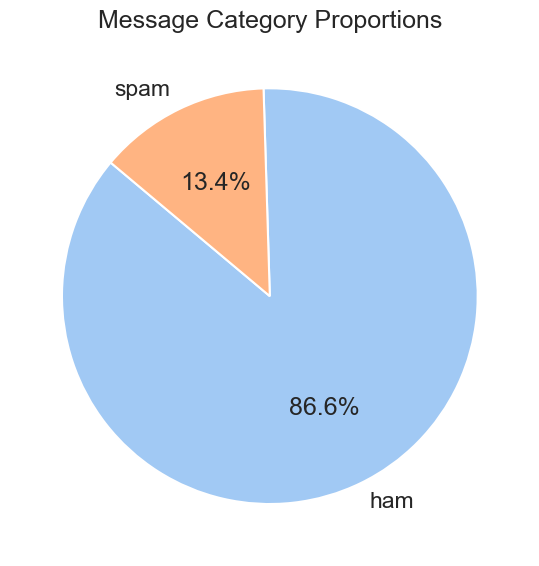

In [85]:
# Calculate Class Percentages
class_percentages = class_counts / class_counts.sum() * 100

# Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='pastel')

# Annotate each bar with the actual message count
for i, count in enumerate(class_counts.values):
    ax.text(i, count + 100, f'{count}', ha='center', va='bottom', fontsize=12)

# Styling
plt.title("Distribution of Message Categories", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Messages", fontsize=12)
plt.ylim(0, max(class_counts.values) * 1.15)  # Add headroom for labels
plt.tight_layout(pad=2.0)
plt.show()

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts.values,
        labels=class_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title("Message Category Proportions")
plt.tight_layout()
plt.show()

**Explanation**

This section analyzes the distribution of message types within the dataset, specifically focusing on the proportions of spam and ham (non-spam) messages. Understanding class distribution is a critical step in exploratory data analysis, especially in classification problems. We begin by calculating the total count and percentage of messages labeled as spam and ham. Two visualizations are used to communicate this information effectively: a bar chart showing the absolute number of messages in each category, and a pie chart showing the relative proportion of each class as a percentage.

The bar chart includes annotations on each bar to display the percentage, providing both a quantitative and visual understanding of the dataset’s composition. The pie chart complements this by illustrating the dominance of one class over the other in a circular, proportion-based view. These visualizations help in quickly identifying any class imbalance, which has implications for model performance and evaluation strategy.

**Summary of Results**

The dataset contains a total of 5,572 SMS messages, of which 4,825 (approximately 86.6%) are labeled as ham and 747 (approximately 13.4%) are labeled as spam. This indicates a significant class imbalance, with ham messages greatly outnumbering spam messages.

Such imbalance is typical in real-world text classification tasks like spam detection, where spam is a minority class. However, this imbalance can lead to biased model performance if not addressed properly during model training and evaluation. For example, a naive model that always predicts “ham” could still achieve high accuracy due to the dominant class. As a result, additional techniques such as stratified sampling, resampling (e.g., SMOTE), or using metrics like precision, recall, and F1-score instead of accuracy alone will be necessary to properly evaluate model effectiveness.

## 2.2 Message Length Analysis


Message length statistics by category:
           count        mean        std  min    25%    50%    75%    max
Category                                                                
ham       4825.0   71.524767  58.453847  2.0   33.0   52.0   93.0  910.0
spam       747.0  138.432396  30.105608  7.0  133.0  149.0  157.0  224.0


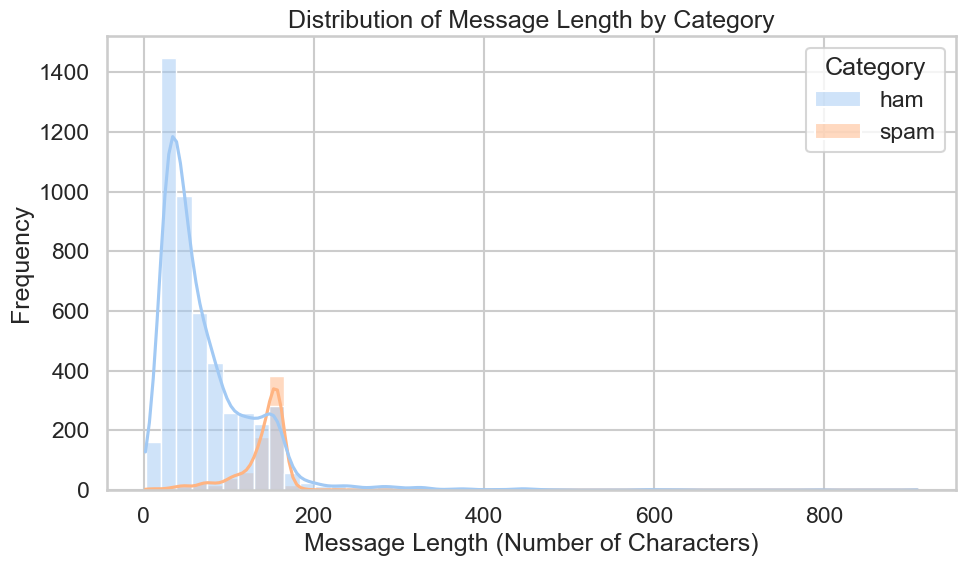

In [83]:
# Add a new column to store the length of each message
df['Message_Length'] = df['Message'].apply(len)

# Show basic statistics for message length per category
print("\nMessage length statistics by category:")
print(df.groupby('Category')['Message_Length'].describe())

# Plot the distribution of message lengths for spam and ham
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Message_Length', hue='Category', bins=50, kde=True, palette='pastel')
plt.title("Distribution of Message Length by Category")
plt.xlabel("Message Length (Number of Characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Explanation**

This section investigates whether message length—defined as the number of characters in each SMS—differs significantly between spam and ham messages. To perform this analysis, a new column was added to the dataset to record the character count for each message. This numerical feature allows for statistical comparison across message types.

Descriptive statistics, including the mean, standard deviation, and quartiles, were calculated for both categories. These values help quantify the average length and variability of messages. A histogram was then used to visualize the distribution of message lengths, separated by category. A kernel density estimate (KDE) was added to highlight the distribution trend and allow for easier comparison.

The purpose of this analysis is to determine whether message length can serve as a useful feature for spam classification. By visualizing and summarizing the data, we can assess whether one category consistently contains longer or shorter messages.

**Summary of Results**

The analysis reveals a clear distinction in message length between spam and ham messages. On average, ham messages are 71.5 characters long, with a standard deviation of 58.5 characters. In contrast, spam messages are significantly longer on average, with a mean length of 138.4 characters and a lower standard deviation of 30.1. This indicates that spam messages tend to be not only longer but also more consistent in length.

The histogram further illustrates this difference. The distribution of ham messages is concentrated in the lower length ranges, with a wider spread, while spam messages are skewed toward the higher end of the spectrum and appear more uniform in size.

These findings suggest that message length is a potentially strong feature for distinguishing spam from ham. Longer, more templated messages are indicative of spam, while shorter, more varied messages tend to be genuine.

## 2.3 Common Words in Spam vs. Ham

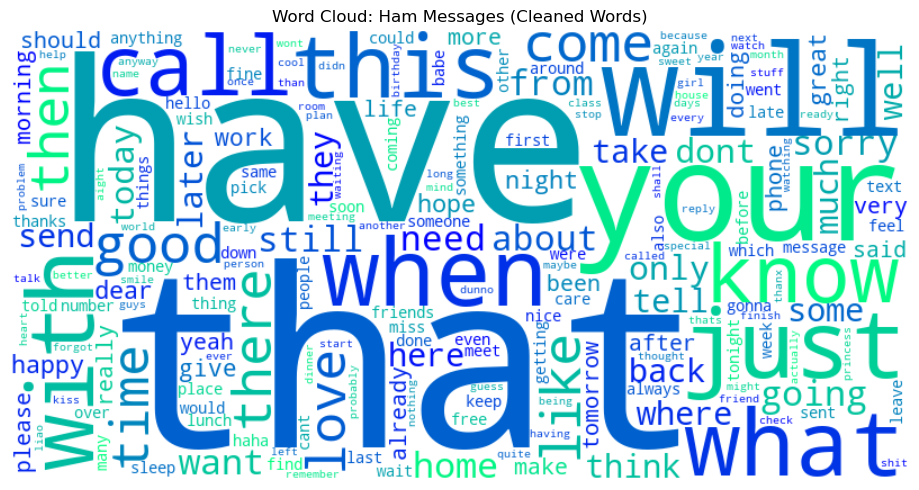

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/3659781097.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ham_top_df, x='Frequency', y='Word', palette='winter')


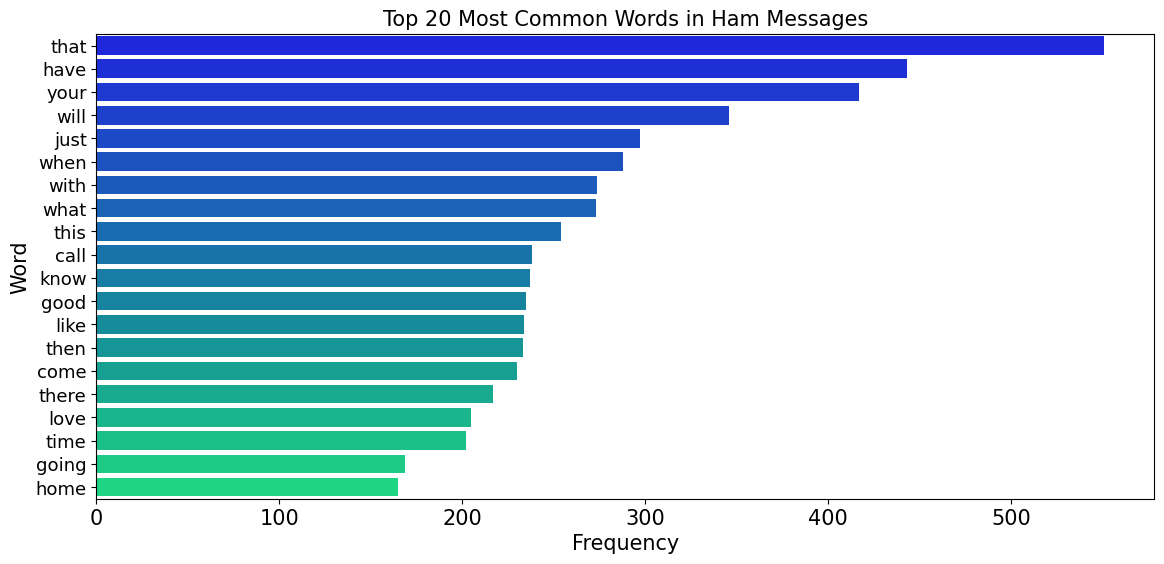

In [31]:
# Word Cloud & Bar Plot for Spam & Ham (Cleaned Version)
import re
from collections import Counter
# Helper: Clean and count words
def get_cleaned_word_freq(messages, top_n=20):
    all_words = []
    for msg in messages:
        # Lowercase, remove punctuation and short words
        words = re.findall(r'\b[a-z]{4,}\b', msg.lower())  # only alphabetic words with ≥ 4 letters
        all_words.extend(words)
    word_freq = Counter(all_words)
    top_words = word_freq.most_common(top_n)
    return word_freq, pd.DataFrame(top_words, columns=['Word', 'Frequency'])

# HAM Message Visualization
ham_messages = df[df['Category'] == 'ham']['Message']
ham_word_freq, ham_top_df = get_cleaned_word_freq(ham_messages)

# Word Cloud for HAM
ham_wc = WordCloud(width=800, height=400, background_color='white', colormap='winter') \
    .generate_from_frequencies(ham_word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Ham Messages (Cleaned Words)")
plt.tight_layout()
plt.show()

# Bar Plot for HAM
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=ham_top_df, x='Frequency', y='Word', palette='winter')

plt.title("Top 20 Most Common Words in Ham Messages", fontsize=15)
plt.xlabel("Frequency", fontsize=15)
plt.ylabel("Word", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=13) 
plt.tight_layout(pad=2.0)
plt.show()

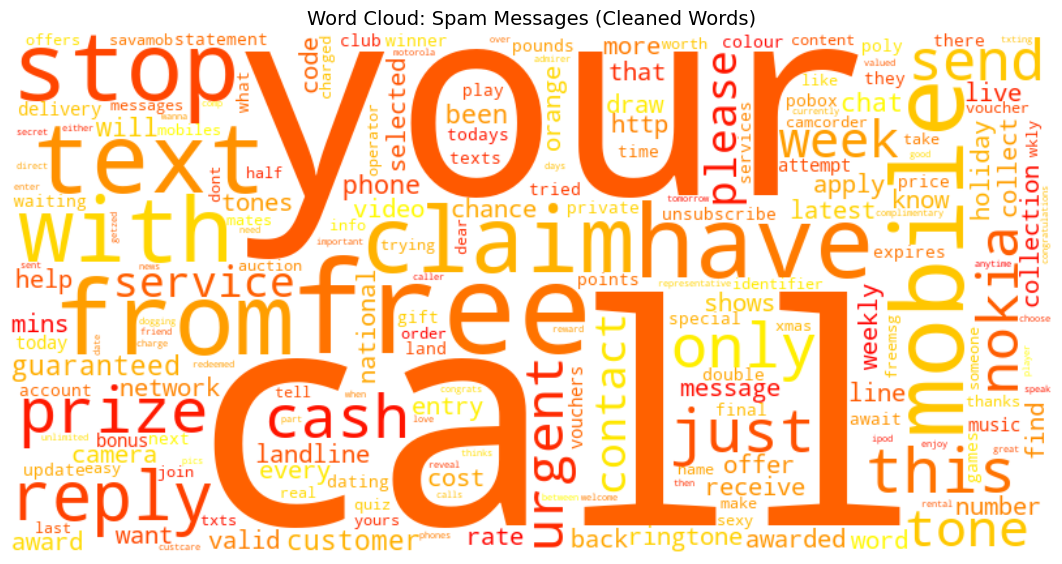

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/2725106309.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spam_top_df, x='Frequency', y='Word', palette='autumn')


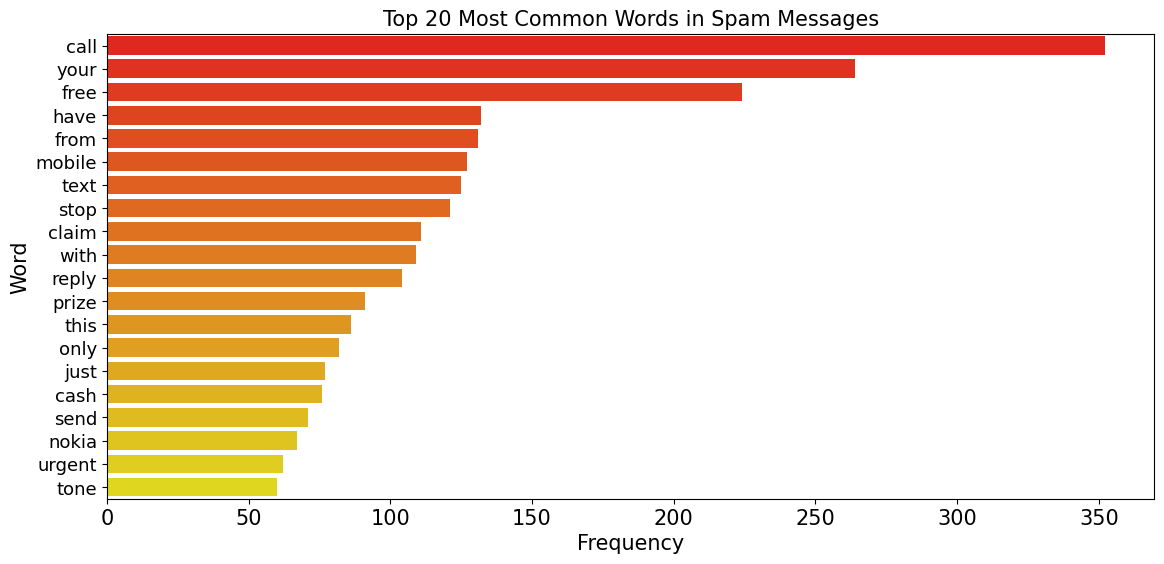

In [33]:
# Extract SPAM messages
spam_messages = df[df['Category'] == 'spam']['Message']

# Get word frequencies and top N words
spam_word_freq, spam_top_df = get_cleaned_word_freq(spam_messages)

# Word Cloud for SPAM
spam_wc = WordCloud(width=800, height=400, background_color='white', colormap='autumn') \
            .generate_from_frequencies(spam_word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Spam Messages (Cleaned Words)", fontsize=14)
plt.tight_layout(pad=2.0)
plt.show()

# Bar Plot for SPAM
plt.figure(figsize=(12, 6))
sns.barplot(data=spam_top_df, x='Frequency', y='Word', palette='autumn')
plt.title("Top 20 Most Common Words in Spam Messages", fontsize=15)
plt.xlabel("Frequency", fontsize=15)
plt.ylabel("Word", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=13) 
plt.tight_layout(pad=2.0)
plt.show()

**Explanation**

This section refines text preprocessing by limiting analysis to alphabetic words containing four or more letters. The intention is to focus on semantically richer terms, eliminating short and potentially ambiguous tokens such as “i,” “a,” “u,” and numeric strings like “2” or “1000.” This stricter filter is common in NLP workflows to enhance signal clarity by excluding high-frequency but low-information words.

The cleaning function applies regex to extract qualifying words from each message, then computes their frequency. Word clouds and bar plots are then generated for both spam and ham messages based on these filtered tokens. This process provides a focused view on the core vocabulary patterns that define each category.

**Summary of Results**

The cleaned word analysis revealed distinct thematic patterns. For ham messages, frequent terms included “that,” “have,” “your,” “will,” “just,” and “when”—words that convey everyday conversation, actions, and personal context. These words align with the informal and relational tone typically seen in non-spam (ham) messages.

Conversely, spam messages were characterized by promotional and transactional terms such as “call,” “free,” “claim,” “stop,” “mobile,” and “reply.” These align closely with known spam patterns emphasizing urgency, offers, or instructions. Numeric codes, symbols, and shorter abbreviations were filtered out in this view, leading to a cleaner but more selective vocabulary profile.

## 2.4 Text Properties (Length, Punctuation)

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/3849850479.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Word_Count', palette='pastel')


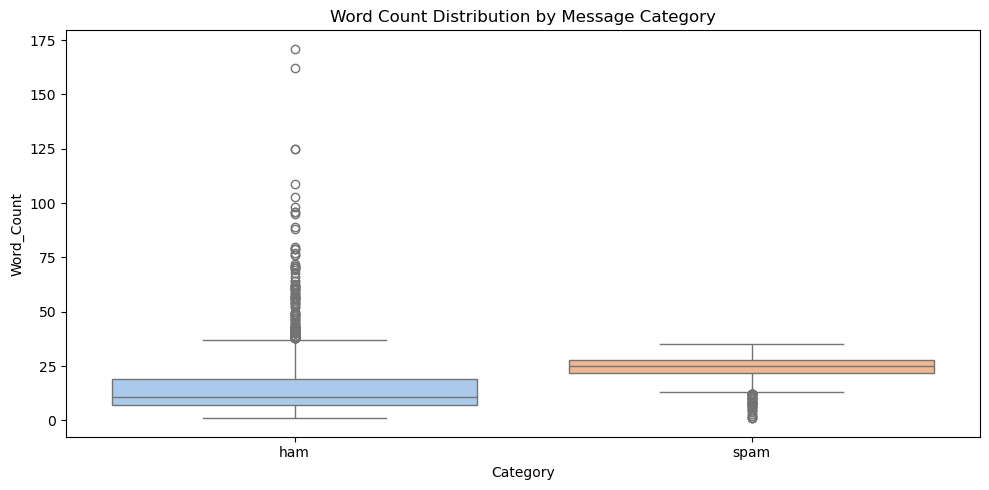

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/3849850479.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Punctuation_Count', palette='pastel')


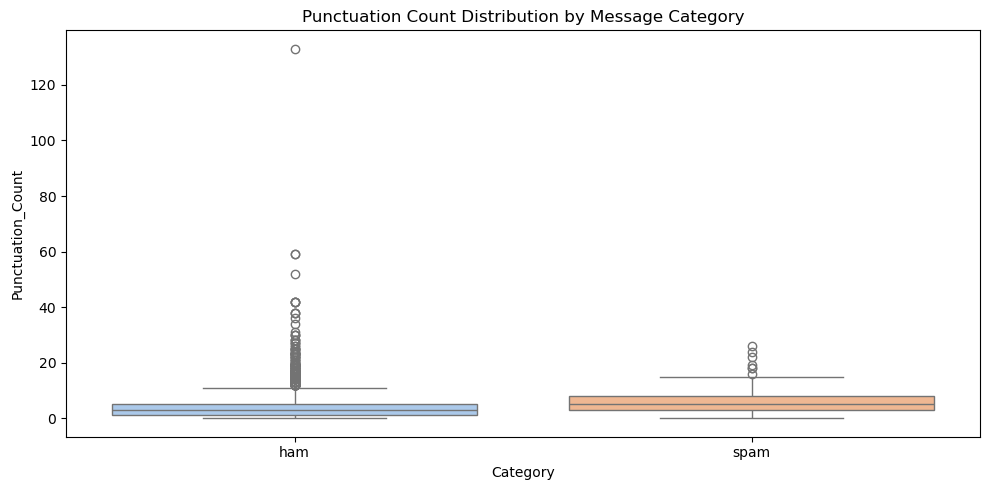


Average Text Features by Category:
          Message_Length  Word_Count  Punctuation_Count
Category                                               
ham            71.524767   14.310259           3.939482
spam          138.432396   23.812584           5.692102


In [35]:
import string

# Function to count punctuation characters in a message
def count_punct(text):
    return sum(1 for char in text if char in string.punctuation)

# Function to count the number of words in a message
def count_words(text):
    return len(text.split())

# Add new columns to the DataFrame for analysis
df['Word_Count'] = df['Message'].apply(count_words)
df['Punctuation_Count'] = df['Message'].apply(count_punct)

# Visualize Word Count by Category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Category', y='Word_Count', palette='pastel')
plt.title("Word Count Distribution by Message Category")
plt.tight_layout()
plt.show()

# Visualize Punctuation Count by Category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Category', y='Punctuation_Count', palette='pastel')
plt.title("Punctuation Count Distribution by Message Category")
plt.tight_layout()
plt.show()

# Display average values by category
print("\nAverage Text Features by Category:")
print(df.groupby('Category')[['Message_Length', 'Word_Count', 'Punctuation_Count']].mean())

**Explanation**

This section analyzes the structural characteristics of text messages—specifically focusing on the number of words and punctuation marks—as quantitative features that can distinguish spam from ham messages. To achieve this, two custom functions are used:

    • count_words() calculates the number of words in a message by splitting the text based on whitespace.

    • count_punct() counts the number of punctuation characters using Python’s built-in string.punctuation.

These metrics are computed for each message and added as new columns to the dataset. Box plots are used to visualize the distribution of word and punctuation counts across the two message categories. Additionally, average values for message length, word count, and punctuation count are calculated to support interpretation.

**Summary of Results**

The results reveal a clear structural difference between spam and ham messages. On average, spam messages are significantly longer and more complex in structure. They contain approximately 23.8 words and 5.7 punctuation marks, compared to 14.3 words and 3.9 punctuation marks in ham messages. The box plots further highlight this distinction, showing tighter distributions and higher medians for spam in both metrics.

These findings support earlier observations: spam messages tend to be more verbose and punctuated, possibly to convey urgency, create emphasis, or mimic formal promotional language. Such features provide valuable signals for building machine learning models, as they complement content-based features (like word frequency) and enhance spam detection accuracy by capturing the behavioral style of spam communication.

## 2.5 Special Character Frequency

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/390247212.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Special_Char_Count', palette='pastel')


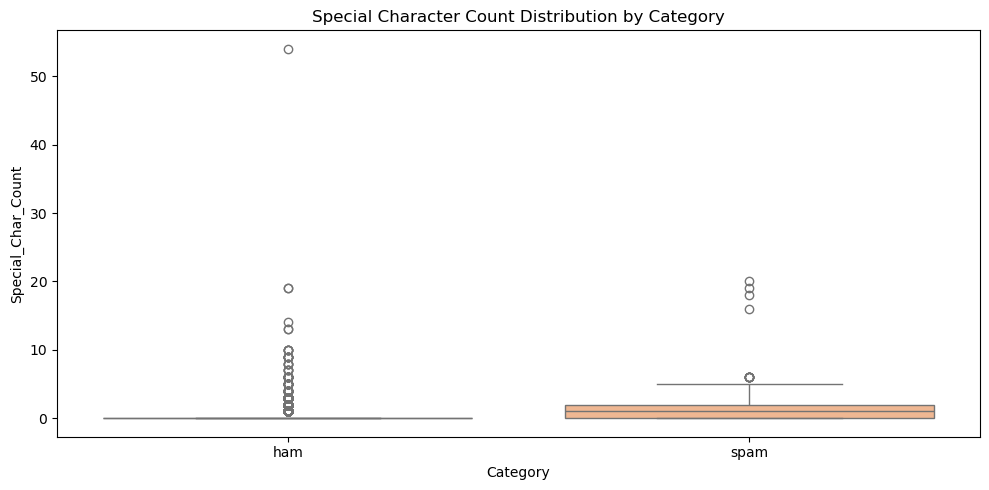


Average special character count per message:
Category
ham     0.438756
spam    1.602410
Name: Special_Char_Count, dtype: float64


In [37]:
# Define the special characters to look for
special_chars = ['$', '£', '%', '!', '@', '#', '*', '&']

# Function to count special characters in a message
def count_special_chars(text):
    return sum(text.count(char) for char in special_chars)

# Apply to DataFrame
df['Special_Char_Count'] = df['Message'].apply(count_special_chars)

# Plot special character count by message category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Category', y='Special_Char_Count', palette='pastel')
plt.title("Special Character Count Distribution by Category")
plt.tight_layout()
plt.show()

# Calculate and print average special character usage
special_char_stats = df.groupby('Category')['Special_Char_Count'].mean()
print("\nAverage special character count per message:")
print(special_char_stats)

**Explanation** 

This section investigates the usage of special characters within SMS messages and compares their distribution across spam and ham categories. A predefined list of commonly used special symbols—such as $, £, %, !, @, #, *, and &—was used to compute the number of such characters in each message. These symbols are often associated with promotional, financial, or urgent content, which are typical traits of spam messages.

The frequency of these characters was calculated using a custom function that sums their occurrences in each message. The results were then visualized using box plots, and the average count of special characters per category was computed to quantify the difference between spam and ham.

**Summary of Results**

The analysis revealed a distinct disparity in the use of special characters between the two message categories. On average, spam messages contained approximately 1.60 special characters, while ham messages included only around 0.44. The box plot visualization further illustrates this gap, showing a higher median and greater variability in the spam category.

These findings suggest that spam messages are more likely to include symbols that emphasize urgency, highlight offers, or simulate official communication. The elevated use of such characters aligns with the persuasive and attention-seeking nature of spam content. This feature proves to be a valuable indicator for classification models, as it helps distinguish commercial or promotional text from casual or personal communication.

# 3. Text Preprocessing

## 3.1 Define Preprocessing Functions

In [39]:
def get_word(text):
    result = nltk.RegexpTokenizer(r'\w+').tokenize(text.lower())  # Use regular expression to split text and convert to lowercase
    return result

def stopword_list(stop):
    lst = stopwords.words('english')  # Load English stopwords and allow appending custom ones
    for stopword in stop:
        lst.append(stopword)
    return lst

def lemmatization(words):  # Lemmatize words to their base form (e.g., "running" → "run")
    lemm = WordNetLemmatizer()
    tokens = [lemm.lemmatize(word) for word in words]
    return tokens

def remove_stopword(stopwords, lst):
    stoplist = stopword_list(stopwords)
    txt = ''
    for idx in range(len(lst)):
        txt += lst[idx]
        txt += '\n'
    cleanwordlist = [word for word in txt.split() if word not in stoplist]
    return cleanwordlist

def preprocess_text(sentence):  # Combine tokenization, lemmatization, and stopword removal
    words = get_word(sentence)              # Split sentence into words
    words_ltz = lemmatization(words)        # Lemmatize words
    removed = remove_stopword('1', words_ltz)  # Remove stopwords (pass '1' as dummy stopword argument)
    return removed

In [41]:
# replace 'ham' value into 0, 'spam' value into 1.
df.replace('ham', 0, inplace =True)
df.replace('spam', 1, inplace =True)

/var/folders/g4/fx0p3zkn7918vh8sq0m1rg8c0000gn/T/ipykernel_19761/205317304.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('spam', 1, inplace =True)


## 3.2 CountVectorizer

In [43]:
vectorizer = CountVectorizer()  # Default uses token_pattern for tokenization
tf_matrix = vectorizer.fit_transform(df['Message'])
feature_names = vectorizer.get_feature_names_out()
tf_matrix = tf_matrix.toarray()

tf = pd.DataFrame(tf_matrix, columns=feature_names)

tf
# Each row represents one email, each column represents the frequency of a word.

,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,zeros,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,ãº1,ã¼
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
idf_vectorizer = TfidfVectorizer()

idf_vectorizer.fit_transform(df['Message'])

idf_vector = idf_vectorizer.idf_

idf = pd.DataFrame(idf_vector, index=feature_names, columns=["IDF"])

idf

,IDF
00,7.227794
000,6.293484
000pes,8.932542
008704050406,8.527076
0089,8.932542
...,...
zoom,8.932542
zouk,8.932542
zyada,8.932542
ãº1,8.932542


## 3.3 tf-idf Transformer

In [47]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{4,}\b',      # Keep only words with length ≥ 4
    stop_words='english',            # Remove English stopwords
)
df_spam = df[df['Category'] == 1]
df_ham = df[df['Category'] == 0]

# Compute TF-IDF for spam messages:
spam_tfidf_matrix = tfidf_vectorizer.fit_transform(df_spam['Message'])
spam_feature_names = tfidf_vectorizer.get_feature_names_out()
spam_tfidf_df = pd.DataFrame(spam_tfidf_matrix.toarray(), columns=spam_feature_names)

# Compute TF-IDF for ham messages:
ham_tfidf_matrix = tfidf_vectorizer.fit_transform(df_ham['Message'])
ham_feature_names = tfidf_vectorizer.get_feature_names_out()
ham_tfidf_df = pd.DataFrame(ham_tfidf_matrix.toarray(), columns=ham_feature_names)


print("Spam TF-IDF shape:", spam_tfidf_df.shape)
print("Ham TF-IDF shape:", ham_tfidf_df.shape)



Spam TF-IDF shape: (747, 2249)
Ham TF-IDF shape: (4825, 5779)


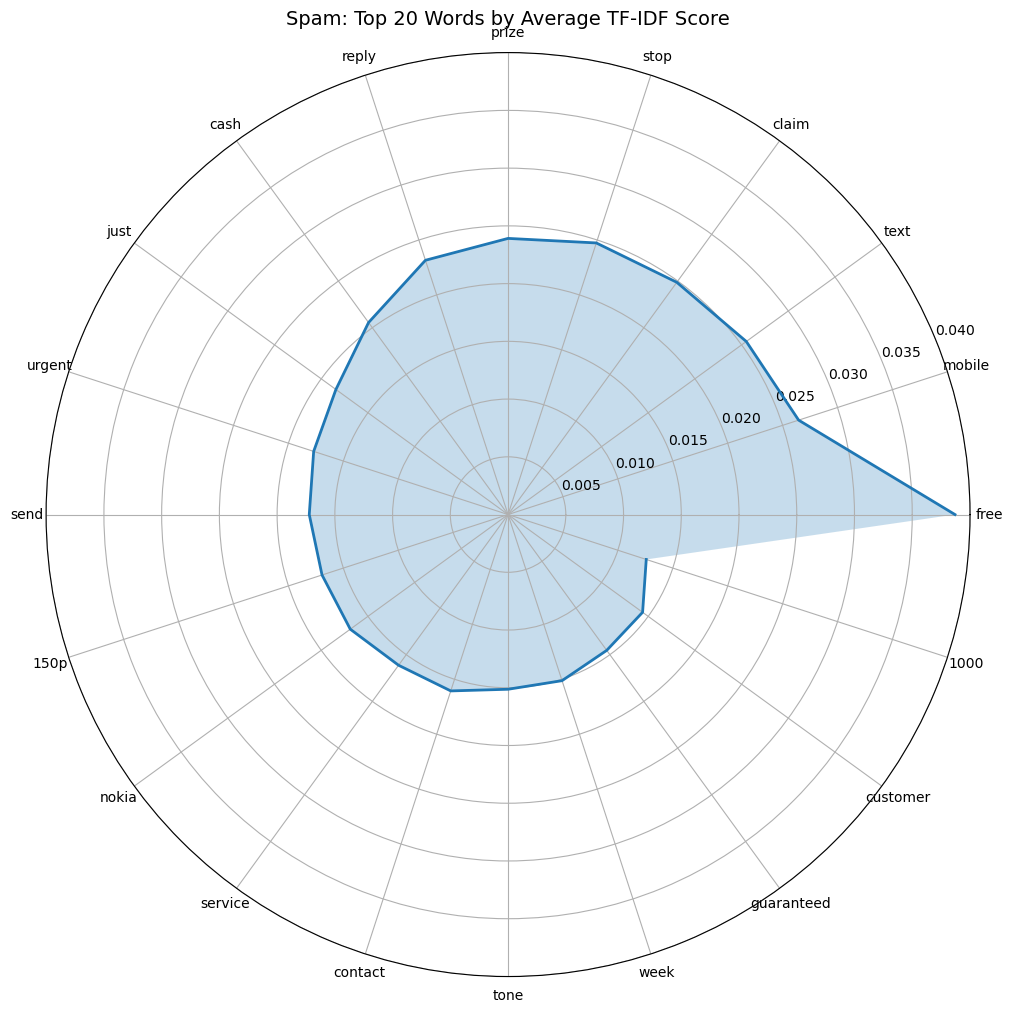

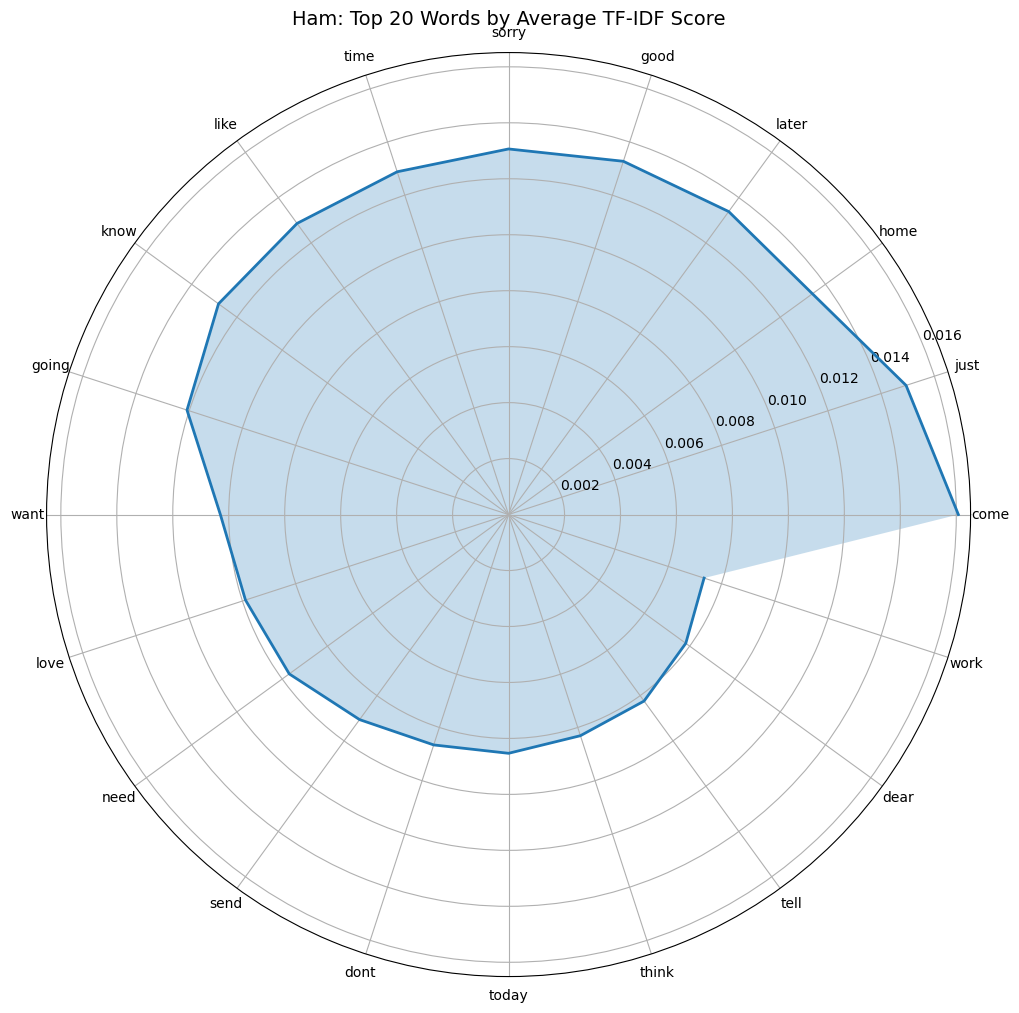

In [55]:
plt.style.use('default')  # Or try 'seaborn', 'ggplot', etc.
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# ----- Spam Radar Chart -----
# Calculate the average TF-IDF value for each word in spam messages
spam_tfidf_scores = spam_tfidf_matrix.toarray().T
spam_mean_tfidf = spam_tfidf_scores.mean(axis=1)

# Sort indices by average score (high to low) and then select the top 20 words
sorted_indices_spam = np.argsort(spam_mean_tfidf)[::-1]
top20_indices_spam = sorted_indices_spam[:20]

# Extract top 20 feature names and scores for spam
top20_features_spam = spam_feature_names[top20_indices_spam]  # Note: spam_feature_names
top20_scores_spam = spam_mean_tfidf[top20_indices_spam]

# Create a radar (polar) plot for spam
plt.figure(figsize=(12, 12))
ax_spam = plt.subplot(111, polar=True)

# Compute angles evenly distributed between 0 and 2π
theta_spam = np.linspace(0, 2 * np.pi, len(top20_features_spam), endpoint=False)

ax_spam.plot(theta_spam, top20_scores_spam, linewidth=2, label='Spam')
ax_spam.fill(theta_spam, top20_scores_spam, alpha=0.25)
ax_spam.set_xticks(theta_spam)
ax_spam.set_xticklabels(top20_features_spam, rotation=45, ha='center', fontsize=10)

plt.title("Spam: Top 20 Words by Average TF-IDF Score", pad=20)
plt.show()

# ----- Ham Radar Chart -----
# Calculate the average TF-IDF value for each word in ham messages
ham_tfidf_scores = ham_tfidf_matrix.toarray().T
ham_mean_tfidf = ham_tfidf_scores.mean(axis=1)

# Sort indices and select the top 20 words for ham
sorted_indices_ham = np.argsort(ham_mean_tfidf)[::-1]
top20_indices_ham = sorted_indices_ham[:20]

# Extract top 20 feature names and scores for ham
top20_features_ham = ham_feature_names[top20_indices_ham]  # Note: ham_feature_names
top20_scores_ham = ham_mean_tfidf[top20_indices_ham]

# Create a radar (polar) plot for ham
plt.figure(figsize=(12, 12))
ax_ham = plt.subplot(111, polar=True)

# Compute angles evenly distributed between 0 and 2π
theta_ham = np.linspace(0, 2 * np.pi, len(top20_features_ham), endpoint=False)

ax_ham.plot(theta_ham, top20_scores_ham, linewidth=2, label='Ham')
ax_ham.fill(theta_ham, top20_scores_ham, alpha=0.25)
ax_ham.set_xticks(theta_ham)
ax_ham.set_xticklabels(top20_features_ham, rotation=45, ha='center', fontsize=10)

plt.title("Ham: Top 20 Words by Average TF-IDF Score", pad=20)
plt.show()


## 3.4 Train-test split

In [57]:
tfdf_vector = TfidfVectorizer(analyzer=preprocess_text)

#  fit_transform 
X = tfdf_vector.fit_transform(df['Message'])

train_X, test_X, train_y, test_y = train_test_split(X, df['Category'], test_size=0.20, random_state=42)

# 4. Model Training (ML)

## 4.1 Model Training

In [59]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Define Models
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "k-NN": KNeighborsClassifier(),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Train, Predict, and Evaluate
ml_results = {}
for name, model in ml_models.items():
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)
    report = classification_report(test_y, predictions, output_dict=True)

    ml_results[name] = {
        "Accuracy": accuracy_score(test_y, predictions),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score'],
        "Confusion Matrix": confusion_matrix(test_y, predictions).tolist()
    }

# Format Results
results_df = pd.DataFrame(ml_results).T
print(results_df)

                     Accuracy Precision    Recall  F1-Score  \
Logistic Regression  0.964126       1.0  0.731544  0.844961   
SVM                  0.978475       1.0  0.838926  0.912409   
Decision Tree        0.965022  0.923077  0.805369  0.860215   
Random Forest        0.979372       1.0  0.845638  0.916364   
k-NN                 0.913901       1.0  0.355705  0.524752   
LightGBM             0.981166  0.977612  0.879195  0.925795   
XGBoost              0.978475   0.94964  0.885906  0.916667   
CatBoost             0.976682     0.992  0.832215  0.905109   

                           Confusion Matrix  
Logistic Regression   [[966, 0], [40, 109]]  
SVM                   [[966, 0], [24, 125]]  
Decision Tree        [[956, 10], [29, 120]]  
Random Forest         [[966, 0], [23, 126]]  
k-NN                   [[966, 0], [96, 53]]  
LightGBM              [[963, 3], [18, 131]]  
XGBoost               [[959, 7], [17, 132]]  
CatBoost              [[965, 1], [25, 124]]  


## 4.2 Compare Evaluation Matrix

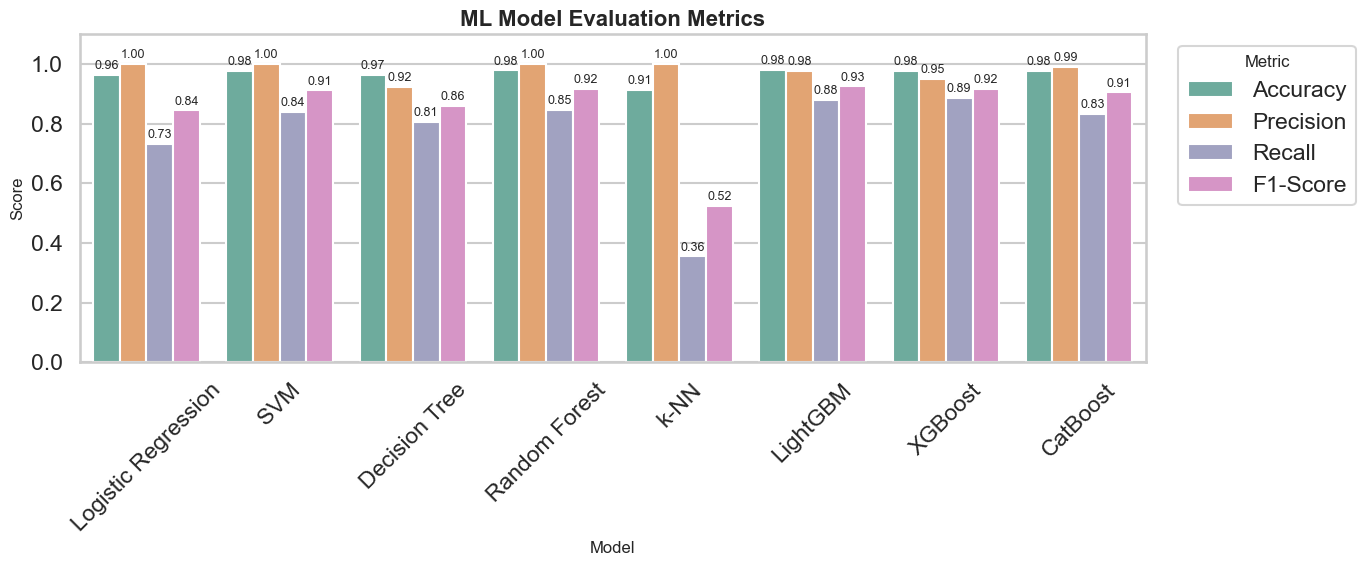

In [61]:
# Prepare data
results_df_reset = results_df.reset_index().rename(columns={'index': 'Model'})
results_melted = pd.melt(
    results_df_reset,
    id_vars=['Model'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    var_name='Metric',
    value_name='Score'
)

# Define custom palette (optional: tweak as you like)
palette = {
    "Accuracy": "#64b5a3",     # Teal green
    "Precision": "#f4a261",    # Soft orange
    "Recall": "#9c9dc6",       # Dusty lavender
    "F1-Score": "#e18acb"      # Soft pink
}

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette=palette
)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2, fontsize=9)

# Styling
plt.title('ML Model Evaluation Metrics', fontsize=16, weight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.legend(title='Metric', title_fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Summary of Results**

The extended evaluation matrix provides a comprehensive comparison of eight machine learning models: Logistic Regression, Support Vector Machine (SVM), Decision Tree, Random Forest, k-Nearest Neighbors (k-NN), LightGBM, XGBoost, and CatBoost. These models were assessed using four key performance metrics: Accuracy, Precision, Recall, and F1-Score.

Among the classic models, Random Forest consistently stood out with high scores across all metrics — achieving 98% Accuracy, 100% Precision, 85% Recall, and 92% F1-Score. This balance of precision and recall indicates a strong ability to correctly classify both spam and ham messages with minimal false positives or negatives.

In contrast, k-NN performed the weakest, particularly in Recall (36%) and F1-Score (52%). Despite perfect Precision (100%), its inability to identify a significant portion of actual spam emails (low recall) suggests poor generalization and highlights its unsuitability for this task.

Among the boosting algorithms, LightGBM and XGBoost demonstrated exceptional and balanced performance, both achieving 98% Accuracy and F1-Scores above 91%. LightGBM in particular achieved the highest Recall (88%) and F1-Score (93%) across all models, suggesting it excels at identifying the minority spam class. CatBoost also performed competitively with 98% Accuracy, 83% Recall, and 91% F1-Score.

SVM and Decision Tree models also showed strong results. SVM achieved the highest Precision (100%) and maintained good balance in Recall and F1-Score (84% and 91%, respectively), while Decision Tree slightly edged ahead in Recall (81%) and maintained solid overall performance.

Overall, the ensemble-based gradient boosting models — especially LightGBM — provided the most robust and balanced classification performance. These results suggest that incorporating boosted decision tree algorithms is a meaningful enhancement to traditional classifiers in spam detection tasks.

## 4.3 Confusion Matrix

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:36:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


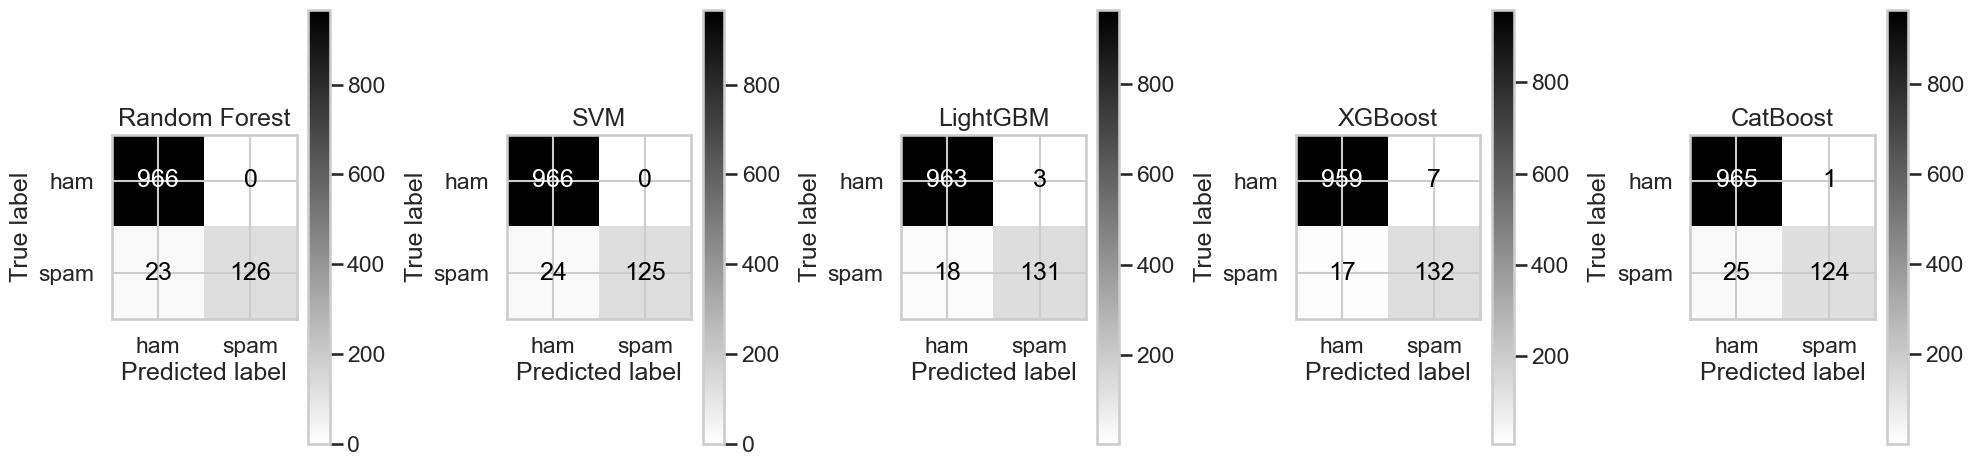

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Define models to compare
models_to_compare = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Fit, predict, and collect predictions
predictions_dict = {}
for name, model in models_to_compare.items():
    model.fit(train_X, train_y)
    preds = model.predict(test_X)
    predictions_dict[name] = preds

# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, len(models_to_compare), figsize=(20, 5))

for ax, (name, preds) in zip(axes, predictions_dict.items()):
    ConfusionMatrixDisplay.from_predictions(
        test_y,
        preds,
        display_labels=['ham', 'spam'],
        cmap='binary',
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Summary of Results**

To deepen the evaluation of model performance, confusion matrices were generated for five top-performing classifiers: Random Forest, SVM, LightGBM, XGBoost, and CatBoost. These visualizations provide insight into how each model handles true positives (spam correctly identified) and false positives (ham misclassified as spam).

Random Forest and SVM both perfectly classified all ham messages and misclassified only 23 and 24 spam messages, respectively, demonstrating high precision. LightGBM and XGBoost stood out by correctly identifying 131 and 132 spam messages—LightGBM doing so with only 3 ham misclassifications and XGBoost with 7—showing the best balance of precision and recall. CatBoost also performed well but showed slightly more variability, with 25 spam messages missed and one ham misclassified.

These five models were selected for comparison based on their superior evaluation metrics across accuracy, precision, recall, and F1-score. Simpler models such as Logistic Regression, Decision Tree, and k-NN were excluded from this analysis as they showed notably lower recall or overall performance, making them less suitable for tasks where false negatives (missed spam) carry higher risk.

## 4.4 Cross Validation

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:11:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:11:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:11:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:11:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

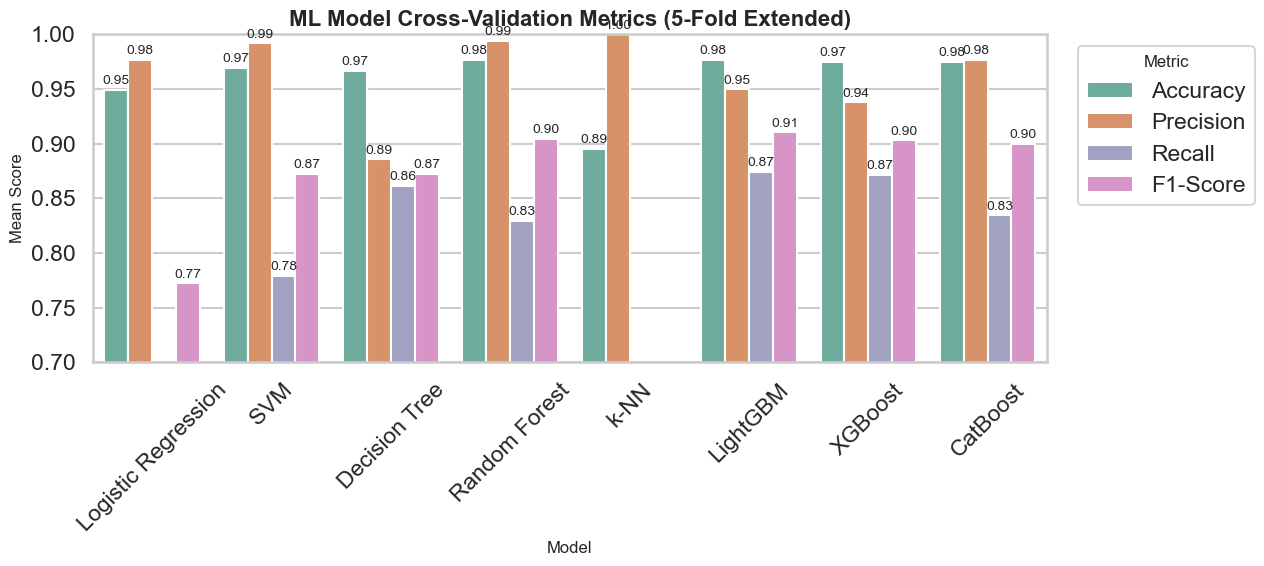

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define stratified k-fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define all models
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "k-NN": KNeighborsClassifier(),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Initialize results storage
cv_results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

# Perform cross-validation
for name, model in ml_models.items():
    cv_results["Model"].append(name)
    cv_results["Accuracy"].append(cross_val_score(model, train_X, train_y, cv=kfold, scoring='accuracy').mean())
    cv_results["Precision"].append(cross_val_score(model, train_X, train_y, cv=kfold, scoring='precision').mean())
    cv_results["Recall"].append(cross_val_score(model, train_X, train_y, cv=kfold, scoring='recall').mean())
    cv_results["F1-Score"].append(cross_val_score(model, train_X, train_y, cv=kfold, scoring='f1').mean())

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)

# Reshape for Seaborn plotting
cv_melted = pd.melt(
    cv_df,
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

# Custom color palette
custom_palette = {
    "Accuracy": "#64b5a3",     # Teal
    "Precision": "#e98d58",    # Orange
    "Recall": "#9c9dc6",       # Lavender
    "F1-Score": "#e18acb"      # Pink
}

# Plotting
sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(13, 6))
ax = sns.barplot(data=cv_melted, x="Model", y="Score", hue="Metric", palette=custom_palette)

# Add annotations
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2, fontsize=10)

# Adjustments
plt.title("ML Model Cross-Validation Metrics (5-Fold Extended)", fontsize=16, weight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Mean Score", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0.7, 1)
plt.legend(title="Metric", title_fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Summary of Results**

In this extended cross-validation analysis, eight machine learning models were evaluated using five-fold cross-validation across four key metrics: accuracy, precision, recall, and F1-score. These metrics provide a more comprehensive view of each model’s performance, especially important in a spam classification context where both false positives and false negatives have significant implications.

Among all models, LightGBM delivered the most balanced performance. It achieved a high accuracy of 0.98 and precision of 0.98, along with the highest recall of 0.87 and a strong F1-score of 0.91. This indicates that LightGBM not only makes correct predictions frequently but is also highly sensitive to identifying spam messages, minimizing false negatives effectively.

XGBoost and CatBoost also performed competitively. XGBoost achieved an accuracy of 0.97 and precision of 0.94, with a recall of 0.87 and an F1-score of 0.90. Similarly, CatBoost produced strong metrics across the board with an accuracy of 0.98, precision of 0.98, recall of 0.83, and an F1-score of 0.90. While these models slightly trailed LightGBM in recall, they remain top-tier candidates due to their consistent performance.

Among the classical machine learning models, Random Forest stood out. It achieved an accuracy of 0.98, precision of 0.99, recall of 0.83, and an F1-score of 0.90. Although its recall is slightly lower than the boosting models, it still performs reliably across all metrics. Logistic Regression and Decision Tree followed with solid, albeit slightly lower, scores. SVM maintained high precision (0.99) but struggled in recall (0.78), indicating it may miss more spam messages than desirable. k-NN, despite perfect precision (1.00), had the lowest recall (0.36) and F1-score (0.52), making it unsuitable for this task where detecting spam is critical.

In summary, LightGBM offers the best overall performance for this classification problem, especially when considering the balance between precision and recall. It is followed closely by XGBoost, CatBoost, and Random Forest, which also show strong generalization and should be considered viable options for deployment or ensemble methods.

# 5. Model Training (DL)

## 5.1 Deep Learning Model Setup

In [67]:
X = df['Message']
y = df['Category']

In [175]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state = 42)    
max_len = max(max(train_X.apply(len).values),max(test_X.apply(len).values)) # Compare the longest sequence lengths in the training and test sets, and take the maximum value as max_len.

**From the train_X and test_X datasets, calculate the length of each data entry (typically a sentence or text) respectively, and take the maximum value as the unified length for all sequences. This way, during padding, each sequence can be padded to the same length, making it easier to feed into the model later.**

In [92]:
def fit_tokenizer(text, oov_token):
    tokenizer = Tokenizer(oov_token=oov_token)  # Initialize the Tokenizer
    tokenizer.fit_on_texts(text)  # Train the Tokenizer using text data
    return tokenizer

**Accept textual data along with a specified “out-of-vocabulary” token (<OOV>), and use Keras’s Tokenizer to construct a dictionary (word_index) that maps each word in the text to a unique integer index. This dictionary helps the model convert words into corresponding vector representations during text processing.**

In [81]:
def seq_padding(sentences, tokenizer, padding, truncating, maxlen):
    # Define a function named seq_padding
    # Parameter descriptions:
    # - sentences: a list of sentences to process, each sentence is a string
    # - tokenizer: a tokenizer used to convert text into sequences of numbers (typically Keras's Tokenizer)
    # - padding: the padding method, usually 'pre' or 'post', determines where to pad zeros
    # - truncating: the truncating method, usually 'pre' or 'post', determines from which end to truncate long sequences
    # - maxlen: the fixed length of the processed sequences. If shorter than this, it will be padded; if longer, it will be truncated based on the truncating strategy

    sequences = tokenizer.texts_to_sequences(sentences)
    # Use the tokenizer's texts_to_sequences method to convert the sentence list into numeric sequences
    # Each word in a sentence will be mapped to a corresponding integer based on the vocabulary, e.g., 'hello' -> 1, 'world' -> 2

    pad_trunc_sequences = pad_sequences(sequences, padding=padding, maxlen=maxlen, truncating=padding)
    # Pad and/or truncate the resulting numeric sequences using pad_sequences method
    # - The padding parameter controls where to add zeros ('pre' means pad at the beginning, 'post' means pad at the end)
    # - The maxlen parameter sets the fixed length for all sequences
    # - The truncating parameter controls how to truncate sequences that exceed the length (in this code, the value of `padding` is reused for truncating)

    return pad_trunc_sequences
    # Return the processed numeric sequences of uniform length

**sentences: A list of text strings, for example ["I love NLP", "Deep learning is fun"].**

**Output:**
sequences: A list of numerical sequences, for example [[1, 2, 3], [4, 5, 6, 7]], where each number corresponds to a word in the vocabulary.

In [86]:
tokenizer = fit_tokenizer(train_X, "<OOV>")  # Set the Out-of-Vocabulary (OOV) token, used to handle words not seen in the training data.

word_index = tokenizer.word_index  # The trained Tokenizer object, which can be used to convert text into sequences of numbers
VOCAB_SIZE = len(word_index)       # The size of the vocabulary, i.e., the number of unique words (excluding the OOV token)

# Convert text to fixed-length numerical sequences
train_X = seq_padding(train_X, tokenizer, 'post', 'post', max_len)
test_X = seq_padding(test_X, tokenizer, 'post', 'post', max_len)

**First, build a Tokenizer on the training data to fix the vocabulary and avoid unseen words appearing in the test data. Then, obtain the vocabulary size VOCAB_SIZE from the generated word_index. Next, convert and pad both the training and test data, transforming all text into fixed-length numerical sequences.**

In [95]:
def callback(MATRIX, PATIENCE):
    callbacks = [
        EarlyStopping(
            monitor=MATRIX,
            patience=PATIENCE,              # PATIENCE: number of epochs to wait; if no improvement, stop training early
            mode='max',                     # Indicates the metric should be maximized
            restore_best_weights=True       # Restore model weights from the epoch with the best monitored metric after training
        ),
        ModelCheckpoint(
            'model.weights.h5',
            monitor=MATRIX,                 
            mode='max',                     # Indicates the metric should be maximized
            save_best_only=True,            # Only save the model with the best monitored metric to avoid overwriting
            save_weights_only=True          # Only save the model weights, not the full model
        )
    ]

    return callbacks

**The purpose of the callback function is to create two callbacks based on the input MATRIX (monitoring metric) and PATIENCE (patience value):**

	• EarlyStopping: Stops training early if the monitored metric does not improve within the specified number of epochs (PATIENCE).
    
	• ModelCheckpoint: At the end of each epoch, checks whether the monitored metric has improved; if so, it saves the current model weights.
**These two callbacks are returned as a list to be used during model training.**

## 5.2 LSTM

In [260]:
from tensorflow.keras.layers import Input
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras import regularizers

def LSTM_model(vocab_size, embedding_dim):
    model = Sequential()

    model.add(Input(shape=(max_len,)))

    model.add(Embedding(vocab_size + 1, embedding_dim))

    # Key modification 2: Use bidirectional LSTM (to ensure LSTM handles sequence both ways)
    model.add(Bidirectional(LSTM(
        64,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(0.001)
    )))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(6, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    # Key modification 3: Explicitly build model (optional)
    model.build(input_shape=(None, max_len))

    return model

model = LSTM_model(VOCAB_SIZE, 100)
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 910, 100)       │       795,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 910, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 6)              │           774 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 880,961 (3.36 MB)

 Trainable params: 880,961 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

**Input layer**: 
Input shape: (batch_size, maxlen)
Output shape: (batch_size, maxlen)

**Embedding layer**: 
Converts integer sequences into word embedding vectors.
Output shape: (batch_size, None, 100) (where embedding_dim=100)

**Bidirectional LSTM layer**: 
Set return_sequences=True.
Output shape: (batch_size, None, 128) (Bidirectional LSTM with 64 units × 2)

**GlobalAveragePooling1D layer**: 
Takes the average across each feature dimension of the sequence.
Output shape: (batch_size, 128)

**Dense layer**: 
Fully connected layer.
Output shape: (batch_size, 6) → final output: (batch_size, 1) (with Sigmoid activation)**

In [105]:
print(train_X.dtype, train_y.dtype, test_X.dtype, test_y.dtype)
history = model.fit(train_X, train_y, epochs = 10, batch_size = 10, callbacks = callback('Accuracy', 2))

test_prediction_label = (model.predict(test_X) >= 0.5).astype("int32")  
test_predict_proba = model.predict(test_X, verbose=0)

LSTM_accuracy = accuracy_score(test_y, test_prediction_label)
LSTM_AUC = roc_auc_score(test_y, test_prediction_label)
LSTM_recall = recall_score(test_y, test_prediction_label)
LSTM_f1 = f1_score(test_y, test_prediction_label)

print(LSTM_accuracy, LSTM_AUC, LSTM_recall, LSTM_f1)

int32 int64 int32 int64
Epoch 1/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 99s 219ms/step - accuracy: 0.8640 - loss: 0.6972
Epoch 2/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `Accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with Accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


446/446 ━━━━━━━━━━━━━━━━━━━━ 111s 248ms/step - accuracy: 0.8620 - loss: 0.5400
Epoch 3/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 113s 253ms/step - accuracy: 0.8761 - loss: 0.4576
Epoch 4/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 115s 257ms/step - accuracy: 0.8638 - loss: 0.4492
Epoch 5/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 113s 254ms/step - accuracy: 0.8647 - loss: 0.4311
Epoch 6/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 113s 254ms/step - accuracy: 0.8842 - loss: 0.3658
Epoch 7/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.9686 - loss: 0.1429
Epoch 8/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 115s 258ms/step - accuracy: 0.9811 - loss: 0.1120
Epoch 9/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 115s 258ms/step - accuracy: 0.9866 - loss: 0.0865
Epoch 10/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 114s 255ms/step - accuracy: 0.9900 - loss: 0.0698
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
0.9820627802690582 0.9555907568746786 0.9194630872483222 0.9319727891156463


## 5.3 CNN

In [255]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras import regularizers

def CNN(vocab_size, embedding_dim):
    # Initialize a sequential model
    model = Sequential()
    
    # Input layer with shape (max_len,)
    model.add(Input(shape=(max_len,)))

    # Embedding layer
    model.add(Embedding(
        input_dim=vocab_size + 1,  # +1 to include padding token (index 0)
        output_dim=embedding_dim,
        input_length=max_len,
        mask_zero=True  # Automatically mask padding in variable-length sequences
    ))

    # First convolutional layer: kernel_size=3 (captures tri-gram features)
    model.add(Conv1D(
        filters=128,                  # 128 filters → 128 feature maps
        kernel_size=3,                # Each filter looks at 3-word windows
        activation='relu',            # ReLU introduces non-linearity
        padding='valid',              # No padding; output size will be reduced
        strides=1,
        kernel_regularizer=regularizers.l2(0.001)
    ))

    # Second convolutional layer: kernel_size=4 (deeper non-linear transformation)
    model.add(Conv1D(
        filters=64,
        kernel_size=4,
        activation='relu',
        padding='valid',
        kernel_regularizer=regularizers.l2(0.001)
    ))

    # Global max pooling over the time dimension (sequence length)
    model.add(GlobalMaxPooling1D())

    # Fully connected (dense) layer
    model.add(Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ))

    # Output layer for binary classification
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(
        loss='binary_crossentropy',  # Binary crossentropy for binary classification tasks
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    return model

model = CNN(VOCAB_SIZE, 100)
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/layer.py:940: UserWarning: Layer 'conv1d_8' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 910, 100)       │       795,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 908, 128)       │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 905, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 869,173 (3.32 MB)

 Trainable params: 869,173 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [173]:
history = model.fit(
    train_X,
    train_y,
    epochs=10,
    batch_size=10,
    validation_split=0.2,  # validation set
    callbacks=callback('Accuracy', 2)  # use the modified callback
)

test_prediction_label = (model.predict(test_X) >= 0.5).astype("int32")
test_predict_proba = model.predict(test_X, verbose=0)

CNN_accuracy = accuracy_score(test_y, test_prediction_label)
CNN_AUC = roc_auc_score(test_y, test_prediction_label)
CNN_recall = recall_score(test_y, test_prediction_label)
CNN_f1 = f1_score(test_y, test_prediction_label)

print(f"CNN Accuracy: {CNN_accuracy:.4f} , CNN RUC score : {CNN_AUC:.4f}, CNN recall : {CNN_recall:.4f}, f1 score: {CNN_f1:.4f}")

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 0.9753 - val_loss: 0.1072
Epoch 2/10
 13/357 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 1.0000 - loss: 0.0234

/opt/anaconda3/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `Accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with Accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9999 - loss: 0.0231 - val_accuracy: 0.9765 - val_loss: 0.1060
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0221 - val_accuracy: 0.9753 - val_loss: 0.1049
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0211 - val_accuracy: 0.9753 - val_loss: 0.1060
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9998 - loss: 0.0198 - val_accuracy: 0.9765 - val_loss: 0.1037
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0186 - val_accuracy: 0.9787 - val_loss: 0.1027
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0177 - val_accuracy: 0.9709 - val_loss: 0.1116
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.9776 - val_loss: 0.1023
Epoch 9/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.976

## 5.4 Final Evaluation and Insights

In [317]:
# Append LSTM scores
cv_results["Model"].append("LSTM")
cv_results["Accuracy"].append(LSTM_accuracy)
cv_results["Recall"].append(LSTM_recall)
cv_results["F1-Score"].append(LSTM_f1)

# Append CNN scores
cv_results["Model"].append("CNN")
cv_results["Accuracy"].append(CNN_accuracy)
cv_results["Recall"].append(CNN_recall)
cv_results["F1-Score"].append(CNN_f1)

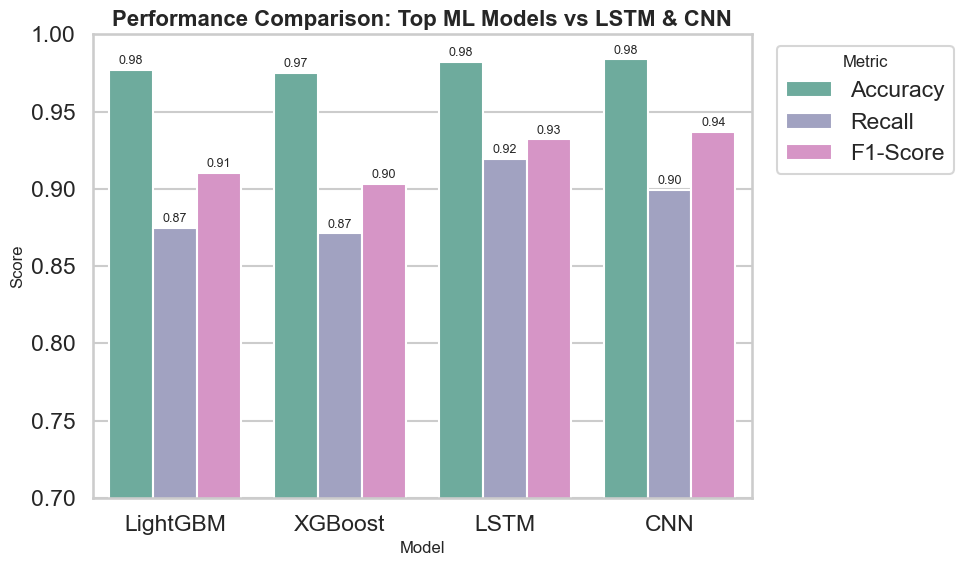

In [319]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the top 2 ML models
top_ml_models = ['XGBoost', 'LightGBM']
ml_top_df = cv_df[cv_df['Model'].isin(top_ml_models)]

# Create DL results DataFrame (excluding precision)
dl_results = pd.DataFrame({
    "Model": ["LSTM", "CNN"],
    "Accuracy": [LSTM_accuracy, CNN_accuracy],
    "Recall": [LSTM_recall, CNN_recall],
    "F1-Score": [LSTM_f1, CNN_f1]
})

# Melt both ML and DL DataFrames
ml_melted = pd.melt(ml_top_df, id_vars=["Model"], value_vars=["Accuracy", "Recall", "F1-Score"],
                    var_name="Metric", value_name="Score")
dl_melted = pd.melt(dl_results, id_vars=["Model"], var_name="Metric", value_name="Score")

# Combine both
comparison_df = pd.concat([ml_melted, dl_melted], ignore_index=True)

# Plot
custom_palette = {
    "Accuracy": "#64b5a3",    # Teal
    "Recall": "#9c9dc6",      # Lavender
    "F1-Score": "#e18acb"     # Pink
}

sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=comparison_df, x="Model", y="Score", hue="Metric", palette=custom_palette)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2, fontsize=9)

# Aesthetics
plt.title("Performance Comparison: Top ML Models vs LSTM & CNN", fontsize=16, weight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.7, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", title_fontsize=12, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Summmary**

This comparison evaluates the top two machine learning models—LightGBM and XGBoost—alongside two deep learning models, LSTM and CNN, using three key evaluation metrics: accuracy, recall, and F1-score.

All four models demonstrated strong performance, with LightGBM, LSTM, and CNN achieving the highest accuracy of 0.98, and XGBoost close behind at 0.97. While accuracy was consistently high across the board, deeper insights come from recall and F1-score—metrics that reflect a model’s ability to correctly identify and classify positive cases.

The deep learning models outperformed their machine learning counterparts in these areas. LSTM achieved a recall of 0.92 and an F1-score of 0.93, while CNN followed closely with a recall of 0.90 and the highest F1-score of 0.94. LightGBM and XGBoost each achieved a recall of 0.87, with F1-scores of 0.91 and 0.90, respectively.

Based on these results, both LSTM and CNN stand out as the strongest candidates. Their consistently high recall and F1-scores make them particularly well-suited for tasks where correctly identifying positive instances is essential, such as spam detection or medical diagnosis.